# Uber Dataset - Exploratory Data Analysis (EDA)

## Overview

The Uber dataset contains approximately 200,000 ride records with features such as fare amount, pickup and drop-off coordinates, passenger count, and pickup date-time. The dataset is highly suitable for Exploratory Data Analysis (EDA) because it includes both temporal and geographical information that can provide meaningful transportation insights.

---

# Key EDA Findings

## Fare Amount Analysis

Most Uber ride fares are concentrated between **$6–$12**, indicating that the majority of rides are short-distance urban trips. The fare distribution is positively skewed, meaning a small number of high-value rides increase the average fare amount.

---

## Passenger Count Analysis

The dataset shows that most rides contain **1–2 passengers**, which reflects normal customer behavior in ride-sharing services. However, some unrealistic values such as passenger count greater than 200 and passenger count equal to 0 were identified.

---

## Data Quality Issues

EDA identified several anomalies and outliers in the dataset, including:

* Negative fare amounts
* Extremely high fare values
* Invalid latitude and longitude values
* Unrealistic passenger counts

These anomalies may be caused by:

* Data-entry errors
* GPS inaccuracies
* Corrupted records
* System-generated logging issues

---

# Temporal Analysis

The `pickup_datetime` column can be used to analyze:

* Peak ride hours
* Weekday vs weekend demand
* Monthly ride trends
* Seasonal transportation patterns

This helps understand customer travel behavior over time.

---

# Geographical Analysis

The pickup and drop-off coordinates can help identify:

* Ride hotspots
* High-demand urban areas
* Airport traffic zones
* Dense transportation regions

Geospatial analysis can provide insights into traffic flow and city mobility patterns.

---

# Recommended EDA Visualizations

The following visualizations are useful for analyzing this dataset:

* Histogram for fare distribution
* Boxplot for outlier detection
* Heatmap for correlation analysis
* Time-series plot for ride trends
* Scatter plot for geographical distribution
* Bar chart for passenger count analysis

---

# Conclusion

Overall, the Uber dataset is highly valuable for Exploratory Data Analysis (EDA). It provides rich temporal and geographical information that can generate meaningful business and transportation insights. Although the dataset contains multiple outliers and invalid records, proper data cleaning can significantly improve the quality and reliability of the analysis.


| Variable Name       | Type          | Description                      | Role in Analysis                     |
| ------------------- | ------------- | -------------------------------- | ------------------------------------ |
| `Unnamed: 0`        | Integer       | Index number of each record      | Identifier / Not useful for analysis |
| `key`               | Object/String | Unique ride ID                   | Record identification                |
| `fare_amount`       | Float         | Total fare charged for the ride  | **Target Variable**                  |
| `pickup_datetime`   | Datetime      | Date and time when ride started  | Time-based analysis                  |
| `pickup_longitude`  | Float         | Pickup location longitude        | Geographical feature                 |
| `pickup_latitude`   | Float         | Pickup location latitude         | Geographical feature                 |
| `dropoff_longitude` | Float         | Drop-off location longitude      | Geographical feature                 |
| `dropoff_latitude`  | Float         | Drop-off location latitude       | Geographical feature                 |
| `passenger_count`   | Integer       | Number of passengers in the ride | Customer behavior analysis           |

## Fare Amount Determination Factors

- The fare_amount in the Uber dataset is influenced by multiple factors related to distance, time, location, and ride conditions. These variables help determine how much a customer is charged for a ride.


| Factor             | Description                          | Impact on Fare Amount                   |
| ------------------ | ------------------------------------ | --------------------------------------- |
| Pickup Location    | Starting point of the ride           | Busy or premium areas may increase fare |
| Drop-off Location  | Destination of the ride              | Longer destinations increase fare       |
| Distance Traveled  | Distance between pickup and drop-off | Higher distance leads to higher fare    |
| Pickup Time        | Time when the ride starts            | Peak hours may increase fare            |
| Traffic Conditions | Road congestion during travel        | Heavy traffic can increase trip cost    |
| Passenger Count    | Number of passengers                 | Larger rides may affect pricing         |
| Weekday/Weekend    | Ride day pattern                     | Weekend demand may affect pricing       |
| Night vs Day Ride  | Ride timing                          | Night rides may have higher charges     |
| Surge Pricing      | High-demand periods                  | Increases fare significantly            |
| Weather Conditions | Rain or bad weather                  | Can increase ride demand and fare       |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df=pd.read_csv('uber.csv')
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [6]:
# Drop unnecessary columns
df.drop(['Unnamed: 0', 'key'], axis=1, inplace=True)

# Convert datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Remove missing values
df.dropna(inplace=True)

# Remove invalid fares
df = df[df['fare_amount'] > 0]

# Remove invalid passenger counts
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

# Remove invalid coordinates
df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_longitude'].between(-180, 180))
]

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (199256, 7)


### Data Cleaning Summary

The dataset was cleaned to improve data quality and ensure reliable analysis. Unnecessary columns (`Unnamed: 0` and `key`) were removed, and the `pickup_datetime` column was converted into datetime format for time-based analysis. Missing values and duplicate records were identified and removed to maintain data consistency. Invalid fare amounts (less than or equal to zero) and unrealistic passenger counts were filtered out. Additionally, geographical coordinates were validated by removing records with invalid latitude and longitude values. 

# Univariate Analysis

## Fare Amount Distribution and Outlier Analysis

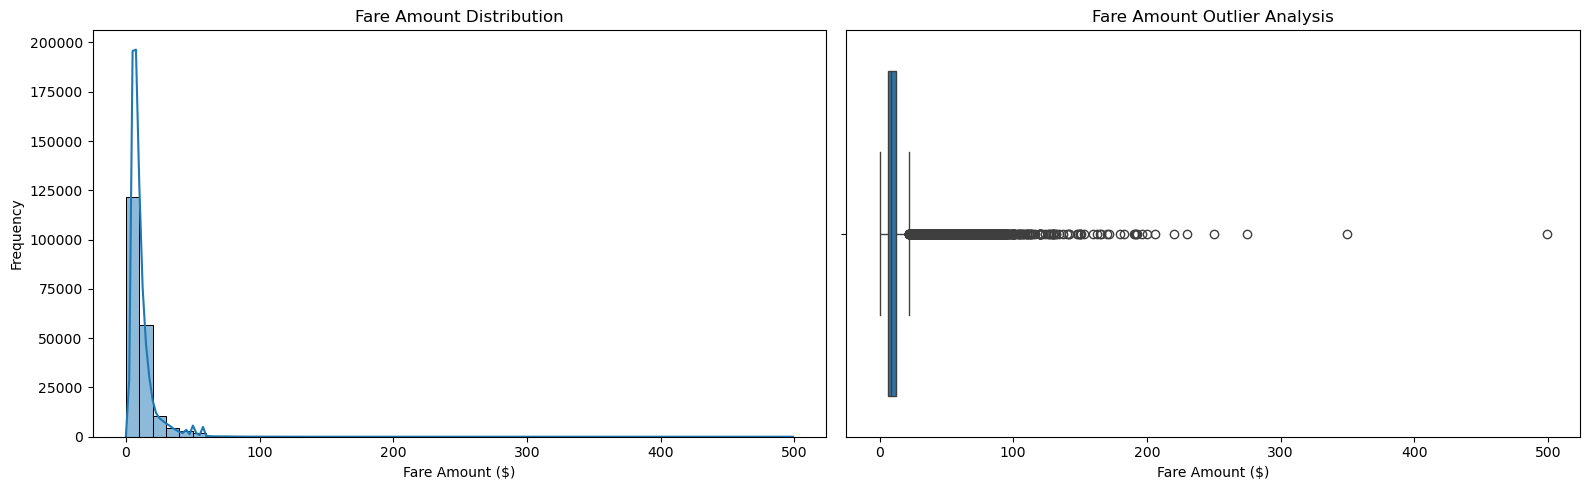

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

# Histogram
sns.histplot(
    df['fare_amount'],
    bins=50,
    kde=True,
    ax=ax[0]
)

ax[0].set_title('Fare Amount Distribution')
ax[0].set_xlabel('Fare Amount ($)')
ax[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(
    x=df['fare_amount'],
    ax=ax[1]
)

ax[1].set_title('Fare Amount Outlier Analysis')
ax[1].set_xlabel('Fare Amount ($)')

plt.tight_layout()
plt.show()

## **Fare Amount Distribution**
-  Most Uber rides have fares between $5 and $20.
- The distribution is highly right-skewed, with most values concentrated at lower fares.
- The frequency of rides decreases significantly as the fare amount increases.
## **Fare Amount Outlier Analysis**
- The boxplot shows a large number of outlier fare values.
- Some fares extend up to nearly $500, far beyond the typical range.
- These extreme values may represent unusual trips or potential data anomalies.

## Passenger Count Distribution Analysis

Passenger Count Statistical Summary


,passenger_count
count,199256.000000
mean,1.689440
std,1.305386
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,6.000000



Passenger Count Frequency:


,count
passenger_count,
1,138405
2,29423
3,8878
4,4275
5,14004
6,4271


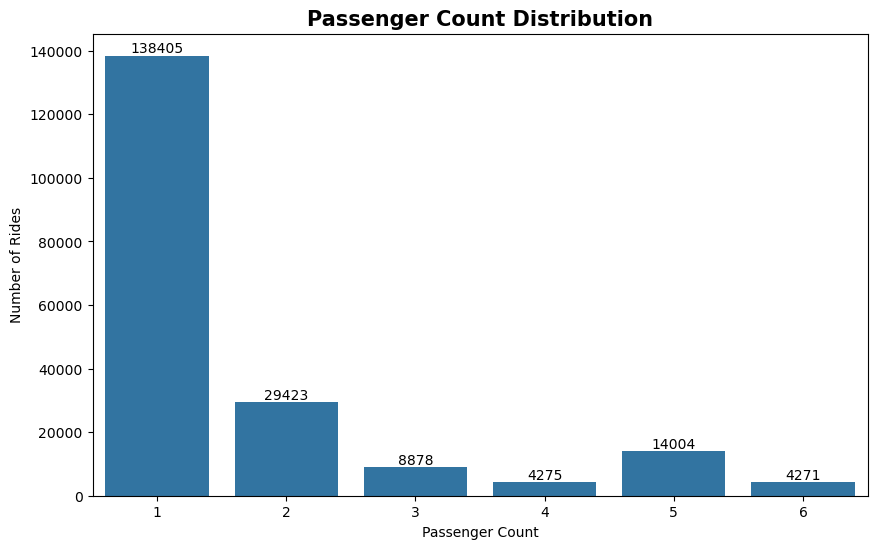

In [8]:
print("Passenger Count Statistical Summary")
display(df['passenger_count'].describe().to_frame())

print("\nPassenger Count Frequency:")
display(df['passenger_count'].value_counts().sort_index().to_frame())

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='passenger_count',
    data=df
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title('Passenger Count Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Rides')

plt.show()

- Single-passenger rides dominate the dataset with 138,405 trips, indicating that most Uber rides are taken by individual passengers.
- Two-passenger rides are the second most common (29,423 trips), while rides with 3 or more passengers are much less frequent.
- Overall, the number of rides decreases as passenger count increases, showing a preference for smaller group trav

## Geographical Coordinates Distribution and Density Analysis

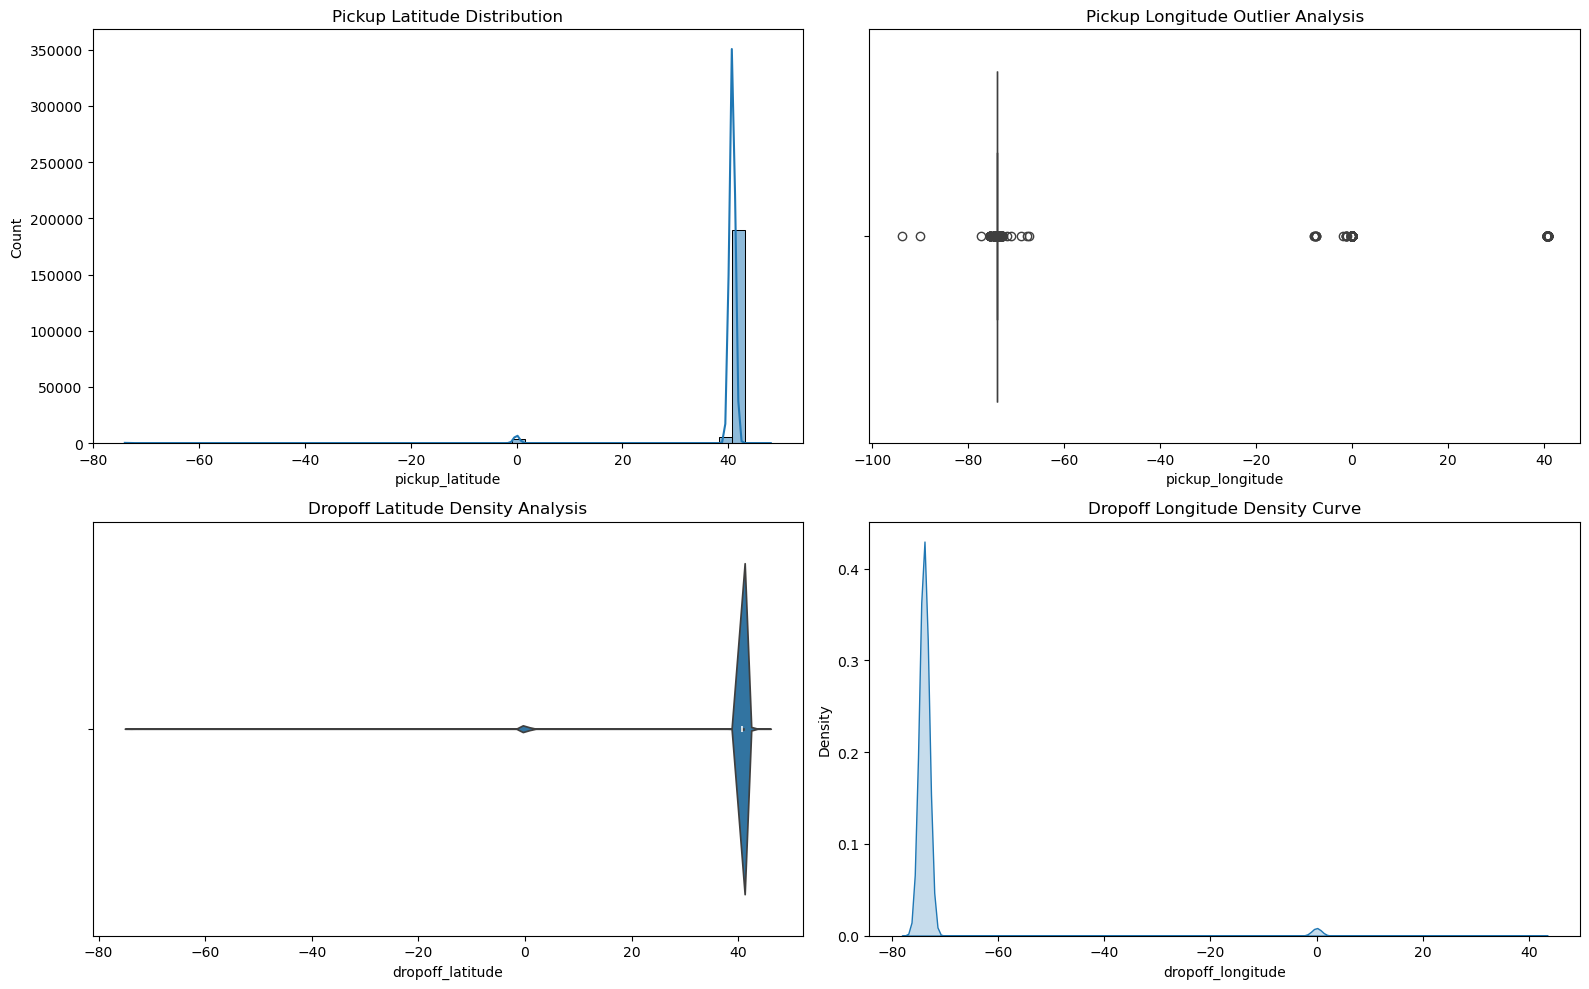

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# GEOGRAPHICAL COORDINATES ANALYSIS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Pickup Latitude - Histogram
sns.histplot(
    df['pickup_latitude'],
    bins=50,
    kde=True,
    ax=axes[0,0]
)
axes[0,0].set_title('Pickup Latitude Distribution')

# 2. Pickup Longitude - Boxplot
sns.boxplot(
    x=df['pickup_longitude'],
    ax=axes[0,1]
)
axes[0,1].set_title('Pickup Longitude Outlier Analysis')

# 3. Dropoff Latitude - Violin Plot
sns.violinplot(
    x=df['dropoff_latitude'],
    ax=axes[1,0]
)
axes[1,0].set_title('Dropoff Latitude Density Analysis')

# 4. Dropoff Longitude - KDE Plot
sns.kdeplot(
    df['dropoff_longitude'],
    fill=True,
    ax=axes[1,1]
)
axes[1,1].set_title('Dropoff Longitude Density Curve')

plt.tight_layout()
plt.show()

* **Most pickup and dropoff locations are clustered around (40°, -74°), indicating rides mainly occur in the New York City area.**
* **A few outliers are present, with latitude ranging from -80° to 50° and longitude from -100° to 40°.**
* **The strong density peak near (40°, -74°) confirms that most trips start and end within the same region.**


# Bivariate analysis

# Fare Amount vs Passenger Count

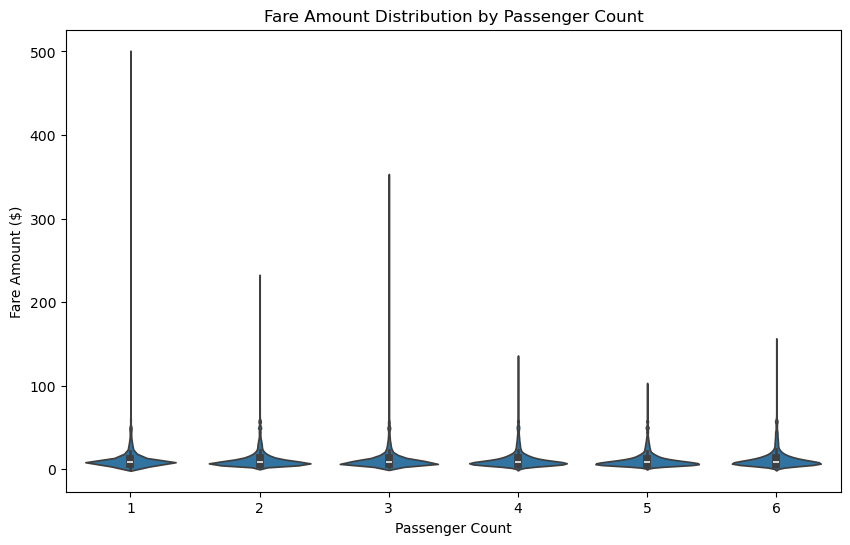

In [10]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='passenger_count',
    y='fare_amount',
    data=df
)

plt.title('Fare Amount Distribution by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')

plt.show()

## **Findings**

* **Passenger counts from 1 to 6 show similar fare distributions, with most fares concentrated between $5 and $20.**
* **All passenger groups contain high-fare outliers, with fares reaching up to nearly $500, indicating a few unusually expensive trips.**


## Bivariate Analysis: Average Fare Amount by Hour and Day of Week

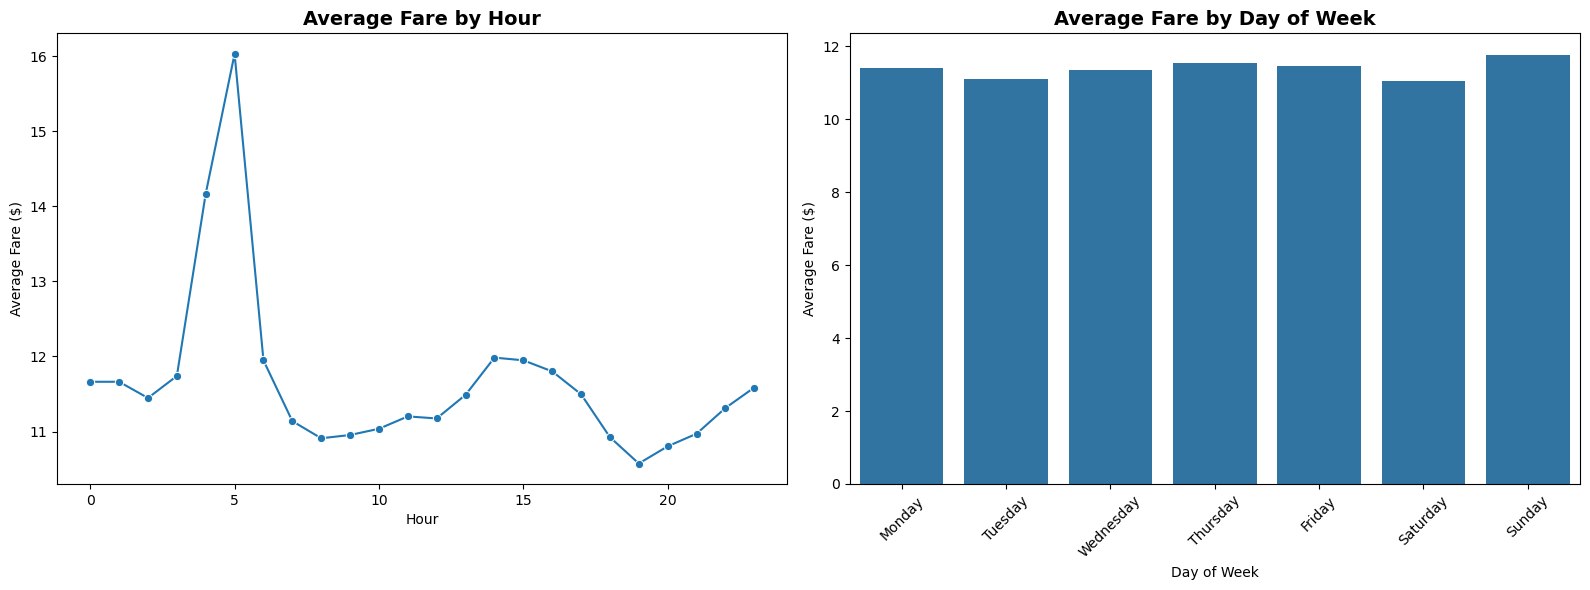

In [15]:
# Create required columns first
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.day_name()

# Average fare by hour
hourly_fare = df.groupby('hour')['fare_amount'].mean().reset_index()

# Average fare by day
day_fare = df.groupby('day_of_week')['fare_amount'].mean().reset_index()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# ==========================================
# BIVARIATE ANALYSIS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fare Amount vs Hour
sns.lineplot(
    x='hour',
    y='fare_amount',
    data=hourly_fare,
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Average Fare by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Fare ($)')

# Fare Amount vs Day of Week
sns.barplot(
    x='day_of_week',
    y='fare_amount',
    data=day_fare,
    order=day_order,
    ax=axes[1]
)

axes[1].set_title('Average Fare by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Fare ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Findings 
- Average fare peaks sharply at 5 AM, reaching around 16, indicating a possible surge in early morning ride demand.
- Most hours of the day maintain stable fares between 11–$12, showing consistent pricing throughout regular operating hours.
- Sunday records the highest average fare, while Saturday has the lowest, though fare differences across weekdays are relatively small.


## Bivariate Analysis: Fare Amount Distribution Across Hours of the Day

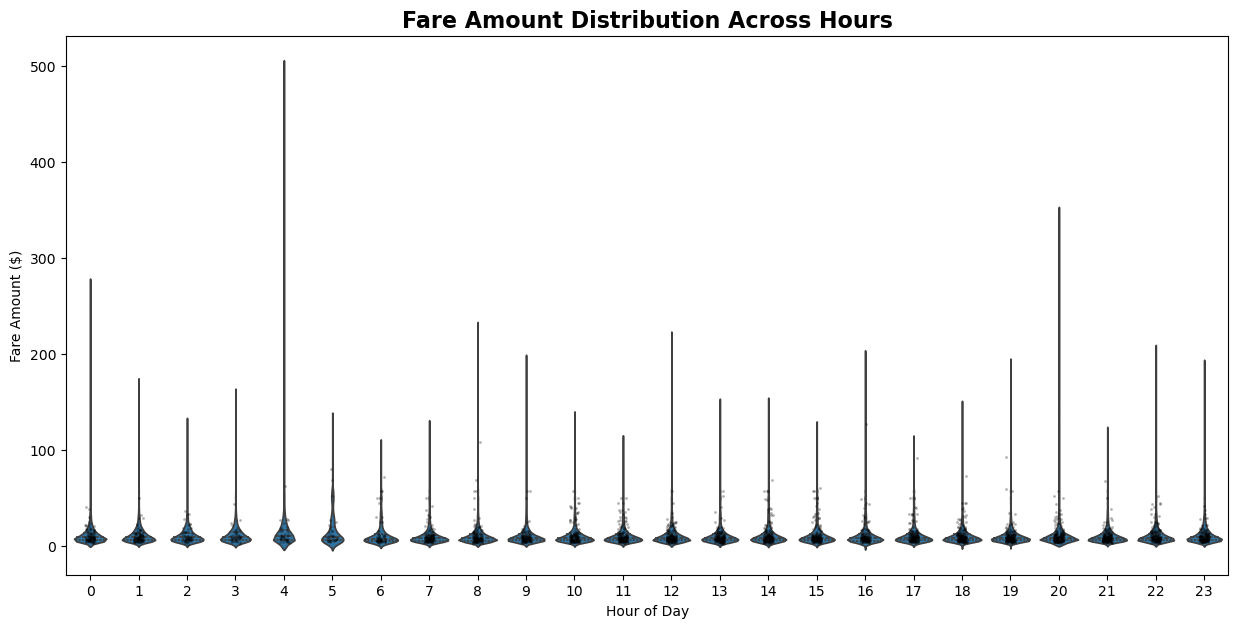

In [16]:
plt.figure(figsize=(15,7))

# Violin Plot
sns.violinplot(
    x='hour',
    y='fare_amount',
    data=df,
    inner='quartile'
)

# Swarm Plot (sample data for speed)
sns.stripplot(
    x='hour',
    y='fare_amount',
    data=df.sample(3000, random_state=42),
    size=2,
    alpha=0.3,
    color='black'
)

plt.title('Fare Amount Distribution Across Hours', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fare Amount ($)')

plt.show()

## Findings 
- The fare distribution remains concentrated around $5–$15 across all hours, indicating stable pricing for most rides.
- Certain hours such as 4 AM and 8 PM show extremely high fare outliers, with fares exceeding $300–$500, suggesting surge pricing or long-distance trips.
- The wide spread and numerous outliers across several hours indicate that ride fares vary significantly depending on demand, trip distance, and time of day.

# **Multivariate visualizations**

## Multivariate Analysis: Correlation Heatmap of Numerical Features

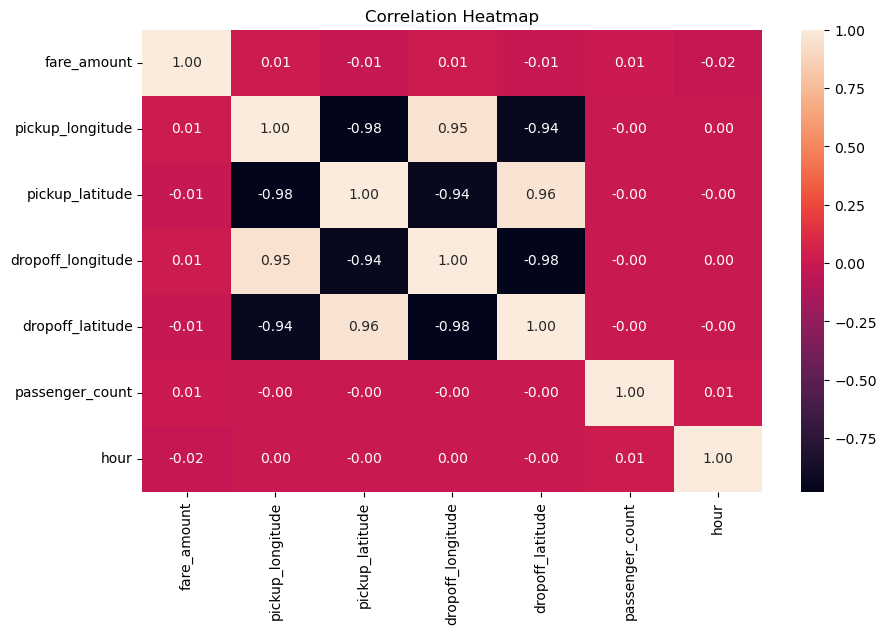

In [19]:
# Correlation Matrix
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


## Findings
- Fare amount has almost no correlation with other variables, as all correlation values are close to 0, indicating fares are not strongly influenced by location coordinates, passenger count, or hour.
- Pickup and dropoff coordinates show very strong correlations (up to ±0.98), suggesting geographical relationships between ride origins and destinations.
- Passenger count and hour have negligible correlations with all other features, indicating they contribute little to linear relationships in the dataset.

## Multivariate Analysis: Fare Amount by Hour and Passenger Count

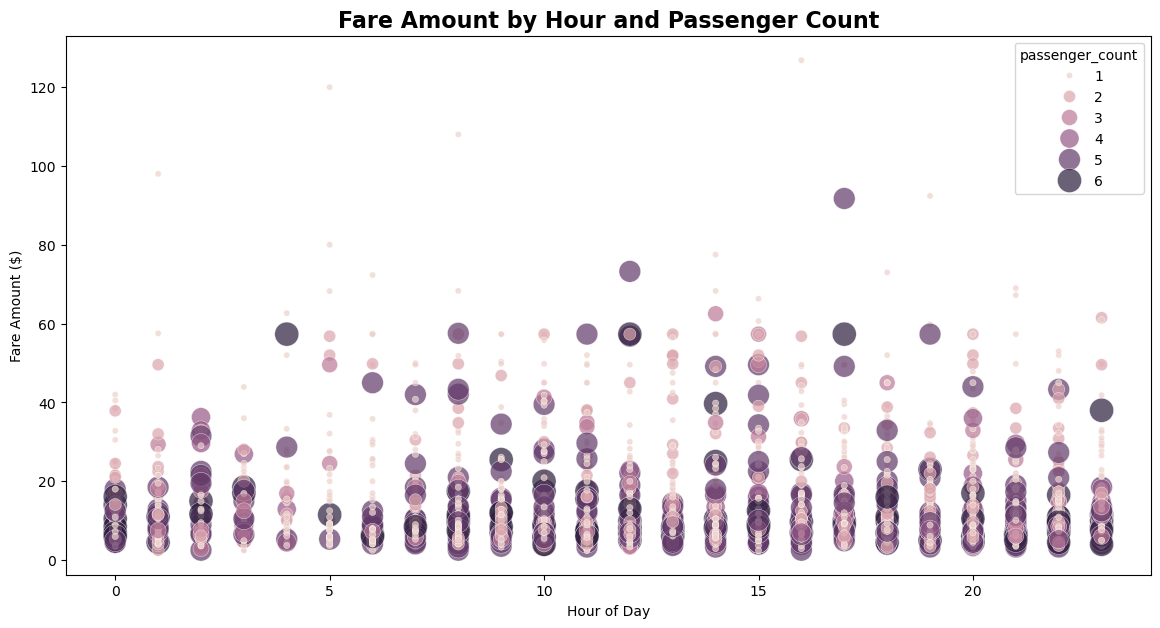

In [20]:
plt.figure(figsize=(14,7))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='hour',
    y='fare_amount',
    size='passenger_count',
    hue='passenger_count',
    alpha=0.7,
    sizes=(20, 300)
)

plt.title('Fare Amount by Hour and Passenger Count', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fare Amount ($)')

plt.show()

## Findings
- Most rides have fare amounts between $5 and $20 across all hours, indicating that the majority of trips are low to moderately priced.
- Higher fare values and outliers are observed during afternoon and evening hours (12 PM–6 PM), where some rides exceed $100.
- Passenger count does not show a strong impact on fare amount, as both small and large passenger groups are distributed across similar fare ranges.

## Multivariate Analysis: Average Fare Amount by Hour and Day of Week

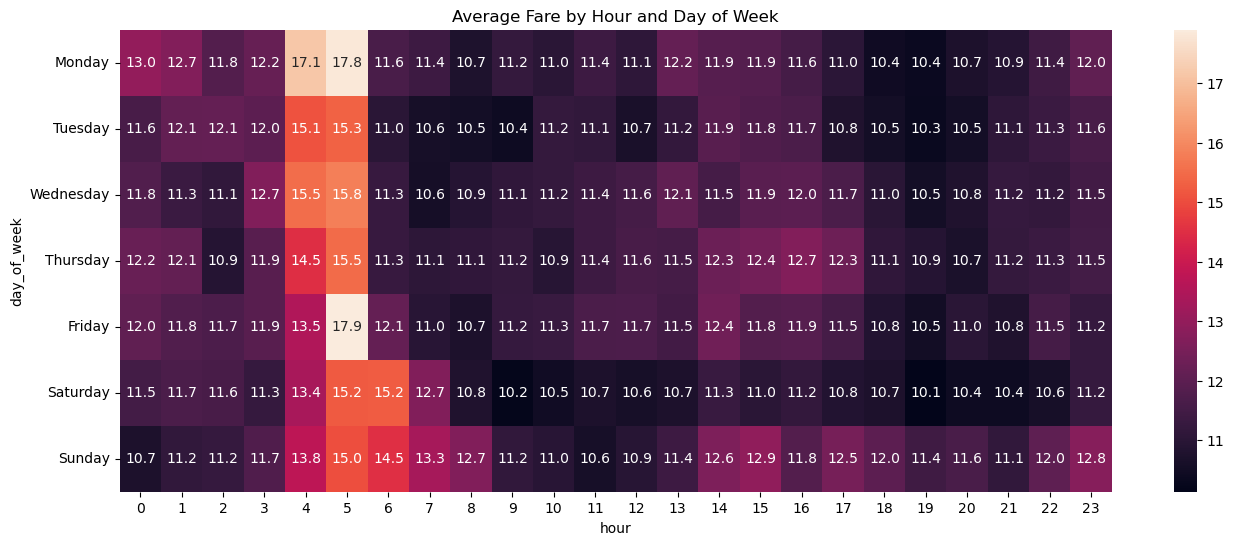

In [21]:
pivot = df.pivot_table(
    values='fare_amount',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

pivot = pivot.reindex(day_order)

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f'
)

plt.title('Average Fare by Hour and Day of Week')

plt.show()

## Findings
- The highest average fares occur during early morning hours (4 AM–6 AM) across all days, with fares reaching $17–$18, indicating strong demand or surge pricing.
- Mid-morning to afternoon hours (8 AM–1 PM) show the lowest average fares, generally ranging between $10–$12.
- Monday and Friday exhibit the highest peak fares, while weekend fares remain relatively stable with fewer extreme fluctuations.

# Executive Summary

Understanding fare patterns is critical for optimizing ride-sharing operations, improving customer satisfaction, and maximizing revenue generation. This report presents a comprehensive exploratory data analysis (EDA) of Uber ride fares using temporal, geographical, and passenger-related variables.

The analysis investigates fare distributions, hourly and weekly pricing trends, passenger behavior, and feature relationships through univariate, bivariate, and multivariate techniques. The findings reveal that fare variability is primarily influenced by time-related factors and ride characteristics, while passenger count exhibits minimal impact on pricing. The report further identifies peak-demand periods and pricing anomalies that can support strategic decision-making for ride allocation and surge-pricing optimization.

# Methodology & Data Preprocessing

To ensure analytical accuracy and data consistency, a structured preprocessing workflow was implemented before conducting the analysis.

## Datetime Feature Engineering

The pickup_datetime variable was converted into a datetime format to enable temporal analysis. Additional features were extracted:

* Hour of Day
* Day of Week

These derived variables allowed detailed investigation of fare behavior across different time periods.

## Data Quality Assessment

The dataset was examined for:

* Missing values
* Duplicate records
* Invalid fare observations

This process ensured that the analysis was based on reliable and high-quality data.

## Feature Standardization

Numerical variables were validated and formatted appropriately to facilitate statistical analysis, visualization, and correlation assessment.

# Key Findings & Analytical Insights

## A. Fare Distribution Analysis (Univariate Analysis)

### Fare Concentration Pattern

The fare amount distribution is heavily concentrated between $5 and $20, indicating that the majority of Uber trips fall within a moderate pricing range.

### Presence of Outliers

The boxplot analysis revealed several extreme fare values exceeding $100 and, in rare cases, surpassing $500.

These outliers likely represent:

* Long-distance rides
* Premium ride categories
* Surge pricing events
* Exceptional trip conditions

### Distribution Characteristics

The fare distribution exhibits positive skewness, meaning that while most rides have relatively low fares, a small number of high-value trips significantly increase the upper tail of the distribution.

---

## B. Temporal Fare Analysis (Bivariate Analysis)

### Hourly Fare Trends

Average fares remain relatively stable throughout most of the day, typically ranging between $10 and $12.

However, significant fare increases occur during:

* Early morning hours (4 AM–6 AM)
* High-demand periods

The highest average fares are observed around 5 AM, suggesting increased demand and reduced driver availability.

### Weekly Fare Patterns

Fare differences across weekdays are relatively small.

Key observations include:

* Sunday records the highest average fare.
* Saturday records the lowest average fare.
* Weekday fare patterns remain largely consistent.

These findings indicate that temporal demand fluctuations affect pricing more strongly than weekly seasonality.

---

## C. Fare Variability Across Hours

### Distribution Stability

The violin plot demonstrates that fare distributions remain relatively consistent throughout the day, with most fares clustered between $5 and $15.

### Pricing Volatility

Certain hours exhibit wider fare spreads and increased variability, particularly during:

* Early morning periods
* Evening peak hours

These intervals experience greater fare uncertainty due to fluctuating demand conditions.

### Extreme Fare Events

Multiple high-value outliers appear across several time periods, confirming that exceptional rides can occur throughout the day rather than during a single peak window.

---

## D. Correlation & Feature Relationship Analysis

### Weak Fare Correlations

The correlation heatmap reveals that fare amount has weak linear relationships with most numerical variables.

This suggests that fare pricing depends on a combination of factors rather than a single dominant feature.

### Strong Geographical Relationships

Pickup and dropoff coordinates exhibit very high correlations, reflecting geographical travel patterns and route dependencies within the dataset.

### Passenger Count Impact

Passenger count demonstrates negligible correlation with fare amount, indicating that pricing is not significantly affected by the number of passengers in a ride.

---

## E. Multivariate Behavioral Insights

### Time vs Fare vs Passenger Count

The bubble chart analysis highlights that:

* Most rides remain within the $5–$20 fare range regardless of passenger count.
* High-fare trips occur across various passenger groups.
* Passenger count has minimal influence on overall fare variation.

### Hour-Day Pricing Matrix

The heatmap combining hour and day of week reveals:

* Highest average fares occur between 4 AM and 6 AM.
* Monday and Friday display the strongest fare peaks.
* Midday hours maintain the most stable pricing patterns.

These results reinforce the importance of temporal demand in determining fare levels.

# Strategic Recommendations

Based on the analytical findings, the following recommendations are proposed:

## 1. Optimize Early-Morning Driver Availability

Since the highest average fares occur during early morning hours, Uber should increase driver availability during these periods through:

* Driver incentives
* Dynamic scheduling
* Peak-hour bonuses

This can reduce excessive surge pricing while improving ride availability.

## 2. Enhance Dynamic Pricing Models

Outlier fare events indicate periods of significant demand imbalance.

Improving predictive surge-pricing algorithms can help:

* Balance supply and demand
* Improve customer satisfaction
* Increase revenue efficiency

## 3. Develop Demand Forecasting Systems

Hourly and weekday patterns can be leveraged to build forecasting models capable of predicting:

* Peak demand periods
* Ride shortages
* Pricing fluctuations

This enables proactive operational planning.

## 4. Investigate Extreme Fare Outliers

Several exceptionally high fares were detected.

Further investigation should determine whether these represent:

* Long-distance trips
* Data-entry errors
* Surge-pricing anomalies

Monitoring such transactions can improve fare transparency and model reliability.

# Business Conclusion

The analysis demonstrates that Uber fare behavior is primarily driven by temporal demand patterns rather than passenger count or isolated numerical features. Most rides maintain a stable fare range between $5 and $20; however, significant fare increases occur during early morning hours and selected peak-demand periods.

The presence of extreme fare outliers highlights the impact of surge pricing and long-distance travel on revenue generation. By improving demand forecasting, optimizing driver allocation, and refining pricing strategies, ride-sharing platforms can enhance operational efficiency, improve customer experience, and maximize profitability.
